In [1]:
import pandas as pd
from pathlib import Path

df = pd.read_csv("data/raw/Locations_and_tiles.csv")
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\n")
print(df.head(20).to_string())

Shape: (19, 1)

Columns: ['location_ID;longitude;latitude;CRS;Satellite;Time;Tilename;Level']


                                                             location_ID;longitude;latitude;CRS;Satellite;Time;Tilename;Level
0;-96 71686781;30  34581793;WGS84 / EPSG:4326;S2B;2024-03-26;S2B_MSIL1C_20240326T165849_N0510_R069_T14RQU_20240326T215236;L1C
      71686781;30  34581793;WGS84 / EPSG:4326;S2B;2024-04-05;S2B_MSIL1C_20240405T165849_N0510_R069_T14RQU_20240405T221905;L1C
1;24  14974583;25  56830695;WGS84 / EPSG:4326;S2A;2024-03-07;S2A_MSIL1C_20240307T085821_N0510_R007_T35RKJ_20240307T094940;L1C
      14974583;25  56830695;WGS84 / EPSG:4326;S2A;2024-03-17;S2A_MSIL1C_20240317T085711_N0510_R007_T34RHP_20240317T095047;L1C
2;57  76533324;38  70446576;WGS84 / EPSG:4326;S2A;2024-04-20;S2A_MSIL1C_20240420T065621_N0510_R063_T40SEH_20240420T085940;L1C
      76533324;38  70446576;WGS84 / EPSG:4326;S2B;2024-03-06;S2B_MSIL1C_20240306T065739_N0510_R063_T40SEH_20240306T085821;L1C
3;50  619507;23    332

In [3]:
import pandas as pd
import numpy as np
import rasterio
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path("data/raw")

# Fix CSV — it's semicolon-separated
df = pd.read_csv(RAW / "Locations_and_tiles.csv", sep=";")
print("CSV shape:", df.shape)
print("Columns:", df.columns.tolist())
print()
print(df.head())

CSV shape: (19, 8)
Columns: ['location_ID', 'longitude', 'latitude', 'CRS', 'Satellite', 'Time', 'Tilename', 'Level']

   location_ID     longitude     latitude                CRS Satellite  \
0            0  -96,71686781  30,34581793  WGS84 / EPSG:4326       S2B   
1            0  -96,71686781  30,34581793  WGS84 / EPSG:4326       S2B   
2            1   24,14974583  25,56830695  WGS84 / EPSG:4326       S2A   
3            1   24,14974583  25,56830695  WGS84 / EPSG:4326       S2A   
4            2   57,76533324  38,70446576  WGS84 / EPSG:4326       S2A   

         Time                                           Tilename Level  
0  2024-03-26  S2B_MSIL1C_20240326T165849_N0510_R069_T14RQU_2...   L1C  
1  2024-04-05  S2B_MSIL1C_20240405T165849_N0510_R069_T14RQU_2...   L1C  
2  2024-03-07  S2A_MSIL1C_20240307T085821_N0510_R007_T35RKJ_2...   L1C  
3  2024-03-17  S2A_MSIL1C_20240317T085711_N0510_R007_T34RHP_2...   L1C  
4  2024-04-20  S2A_MSIL1C_20240420T065621_N0510_R063_T40SEH_2...   L1C 

In [5]:
# Find all image tiffs
all_files = sorted(RAW.glob("*_nonorm_bands20m.tiff"))
print(f"Total image files: {len(all_files)}")
print(f"\nSample filenames:")
for f in all_files[:5]:
    print(" ", f.name)

# Check for label files (might have different suffix)
label_files = sorted(RAW.glob("*label*"))
mask_files  = sorted(RAW.glob("*mask*"))
print(f"\nLabel files found: {len(label_files)}")
print(f"Mask files found : {len(mask_files)}")
if label_files:
    print("Sample label:", label_files[0].name)

Total image files: 804

Sample filenames:
  0___0_S2B_20240326T165849_R1000_nonorm_bands20m.tiff
  0___0_S2B_20240405T165849_R1000_nonorm_bands20m.tiff
  0___1_S2A_20240307T085821_R1000_nonorm_bands20m.tiff
  0___1_S2A_20240317T085711_R1000_nonorm_bands20m.tiff
  0___2_S2A_20240420T065621_R1000_nonorm_bands20m.tiff

Label files found: 1
Mask files found : 0
Sample label: label


In [7]:
import re

def parse_filename(path):
    name = path.stem  # remove .tiff
    # Pattern: {id}___{loc}_{sat}_{date}_R{rate}_nonorm_bands20m
    m = re.match(r"(\d+)___(\d+)_(S2[AB])_(\d{8}T\d{6})_R(\d+)_nonorm_bands20m", name)
    if m:
        return {
            "sample_id"    : int(m.group(1)),
            "location_id"  : int(m.group(2)),
            "satellite"    : m.group(3),
            "date"         : m.group(4),
            "emission_rate": int(m.group(5)),
            "path"         : path
        }
    return None

records = [parse_filename(f) for f in all_files]
records = [r for r in records if r is not None]
meta_df = pd.DataFrame(records)

print("Parsed records:", len(meta_df))
print()
print(meta_df[["sample_id","location_id","satellite","date","emission_rate"]].head(10))
print()
print("Emission rates found:", sorted(meta_df["emission_rate"].unique()))
print("Location IDs found  :", sorted(meta_df["location_id"].unique()))

Parsed records: 804

   sample_id  location_id satellite             date  emission_rate
0          0            0       S2B  20240326T165849           1000
1          0            0       S2B  20240405T165849           1000
2          0            1       S2A  20240307T085821           1000
3          0            1       S2A  20240317T085711           1000
4          0            2       S2A  20240420T065621           1000
5          0            2       S2B  20240306T065739           1000
6          0            3       S2A  20240314T070651           1000
7          0            3       S2B  20240617T070629           1000
8          0            5       S2B  20240311T160949           1000
9          0            5       S2B  20240520T160829           1000

Emission rates found: [np.int64(1000)]
Location IDs found  : [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(8), np.int64(9)]


In [9]:
sample_path = all_files[0]
print("Opening:", sample_path.name)

with rasterio.open(sample_path) as src:
    print(f"Bands : {src.count}")
    print(f"Size  : {src.width} x {src.height}")
    print(f"Dtype : {src.dtypes[0]}")
    img = src.read().astype(np.float32)  # shape: (13, H, W)

print(f"\nImage array shape: {img.shape}")
print("\nPer-band statistics:")
for i in range(img.shape[0]):
    b = img[i]
    print(f"  Band {i+1:2d}: min={b.min():8.1f}  max={b.max():8.1f}  mean={b.mean():.1f}")

Opening: 0___0_S2B_20240326T165849_R1000_nonorm_bands20m.tiff
Bands : 13
Size  : 512 x 512
Dtype : float64

Image array shape: (13, 512, 512)

Per-band statistics:
  Band  1: min=  2064.0  max=  4367.0  mean=2197.7
  Band  2: min=  1503.0  max= 10175.0  mean=1960.5
  Band  3: min=  1389.0  max= 10577.0  mean=1974.7
  Band  4: min=  1216.0  max= 11584.0  mean=1687.0
  Band  5: min=  1291.0  max=  8504.0  mean=2208.9
  Band  6: min=  1304.0  max=  9118.0  mean=3611.6
  Band  7: min=  1239.0  max=  9204.0  mean=4064.0
  Band  8: min=  1053.0  max= 11189.0  mean=4085.8
  Band  9: min=  1253.0  max=  9207.0  mean=4372.8
  Band 10: min=  1131.0  max=  3025.0  mean=2372.8
  Band 11: min=  1012.0  max=  1024.0  mean=1016.6
  Band 12: min=  1183.6  max= 11122.0  mean=3090.1
  Band 13: min=   892.2  max= 11337.0  mean=2088.8


In [11]:
# Sentinel-2 band order in this dataset: B1..B12 + B8A
# B11 = index 10, B12 = index 11
b11 = img[10]
b12 = img[11]

eps = 1e-6
ratio = (b12 + eps) / (b11 + eps)
diff  = b12 - b11

print("B11  range:", b11.min(), "->", b11.max())
print("B12  range:", b12.min(), "->", b12.max())
print("Ratio range:", ratio.min().round(3), "->", ratio.max().round(3))
print("Diff  range:", diff.min(), "->", diff.max())

B11  range: 1012.0 -> 1024.0
B12  range: 1183.6384 -> 11122.0
Ratio range: 1.168 -> 10.872
Diff  range: 170.63843 -> 10099.0


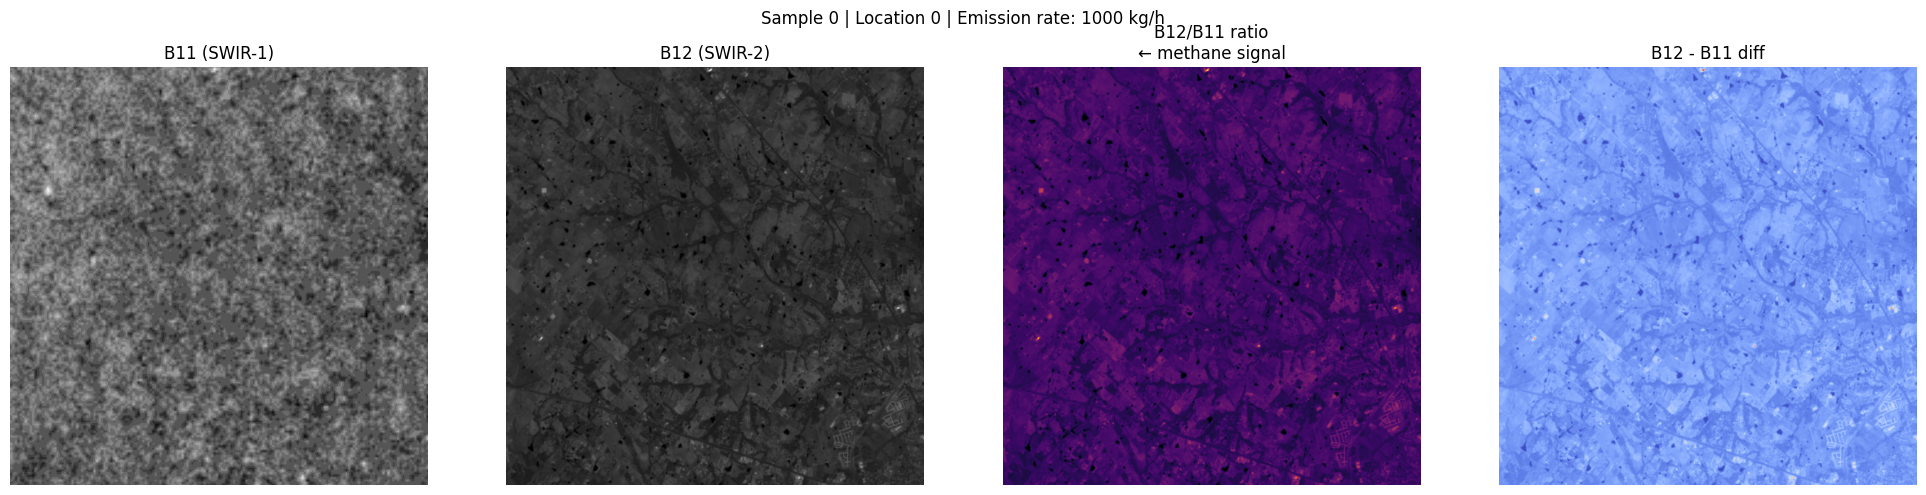

Saved to outputs/figures/sample_visualization.png


In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(b11, cmap="gray")
axes[0].set_title("B11 (SWIR-1)")

axes[1].imshow(b12, cmap="gray")
axes[1].set_title("B12 (SWIR-2)")

axes[2].imshow(ratio, cmap="inferno")
axes[2].set_title("B12/B11 ratio\n← methane signal")

axes[3].imshow(diff, cmap="coolwarm")
axes[3].set_title("B12 - B11 diff")

sample_info = parse_filename(sample_path)
plt.suptitle(
    f"Sample {sample_info['sample_id']} | Location {sample_info['location_id']} | "
    f"Emission rate: {sample_info['emission_rate']} kg/h",
    fontsize=12
)

for ax in axes:
    ax.axis("off")

plt.tight_layout()
plt.savefig("outputs/figures/sample_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/figures/sample_visualization.png")

In [15]:
import os

label_path = RAW / "label"
print("Is directory:", label_path.is_dir())
print("Is file:", label_path.is_file())

if label_path.is_dir():
    label_contents = sorted(label_path.iterdir())
    print(f"\nFiles inside label/: {len(label_contents)}")
    for f in label_contents[:10]:
        print(" ", f.name)

Is directory: True
Is file: False

Files inside label/: 804
  0___0_S2B_20240326T165849_R1000_bin_label.tiff
  0___0_S2B_20240405T165849_R1000_bin_label.tiff
  0___1_S2A_20240307T085821_R1000_bin_label.tiff
  0___1_S2A_20240317T085711_R1000_bin_label.tiff
  0___2_S2A_20240420T065621_R1000_bin_label.tiff
  0___2_S2B_20240306T065739_R1000_bin_label.tiff
  0___3_S2A_20240314T070651_R1000_bin_label.tiff
  0___3_S2B_20240617T070629_R1000_bin_label.tiff
  0___5_S2B_20240311T160949_R1000_bin_label.tiff
  0___5_S2B_20240520T160829_R1000_bin_label.tiff


In [17]:
# Read first few label files
label_files_list = sorted(label_path.glob("*")) if label_path.is_dir() else []

if len(label_files_list) > 0:
    sample_label = label_files_list[0]
    print("Label file name:", sample_label.name)
    print("Label suffix:", sample_label.suffix)

    if sample_label.suffix in ['.tiff', '.tif']:
        with rasterio.open(sample_label) as src:
            lbl = src.read(1)
            print("Label shape :", lbl.shape)
            print("Label dtype :", lbl.dtype)
            print("Unique values:", np.unique(lbl))
            print("Sum (plume px):", lbl.sum())
    elif sample_label.suffix == '.npy':
        lbl = np.load(sample_label)
        print("Label shape  :", lbl.shape)
        print("Unique values:", np.unique(lbl))
    elif sample_label.suffix == '.csv':
        print(pd.read_csv(sample_label).head())
    else:
        print("Unknown format — raw bytes:", open(sample_label,'rb').read(200))
else:
    print("label is not a directory — checking if it's a CSV or npy")
    if (RAW / "label").with_suffix('.csv').exists():
        print(pd.read_csv(RAW / "label.csv").head())
    elif (RAW / "label").with_suffix('.npy').exists():
        lbl = np.load(RAW / "label.npy")
        print("Shape:", lbl.shape, "Unique:", np.unique(lbl))

Label file name: 0___0_S2B_20240326T165849_R1000_bin_label.tiff
Label suffix: .tiff
Label shape : (512, 512)
Label dtype : float64
Unique values: [0.00000000e+00 6.47780986e-04 7.54227234e-04 1.00410047e-03
 1.86282256e-03 3.12390354e-03 4.11847142e-03 4.34781434e-03
 4.34781434e-03 4.47455701e-03 4.90472721e-03 5.22958276e-03
 6.74998687e-03 6.83257648e-03 7.77403209e-03 7.81156662e-03
 8.37148234e-03 8.81364751e-03 1.01042552e-02 1.09362107e-02
 1.10530703e-02 1.13543296e-02 1.14609593e-02 1.17616775e-02
 1.29595459e-02 1.47604305e-02 1.63642534e-02 1.64410029e-02
 1.67947334e-02 1.92044099e-02 1.96459614e-02 2.00742593e-02
 2.21233439e-02 2.21631060e-02 2.23846375e-02 2.47778191e-02
 2.69534731e-02 2.80614896e-02 2.89626313e-02 2.90099116e-02
 2.97162055e-02 3.29595767e-02 3.39848775e-02 3.78766990e-02
 3.78766990e-02 3.79886233e-02 3.92790277e-02 4.24807955e-02
 4.24977466e-02 4.32127650e-02 4.41429506e-02 4.50131208e-02
 4.63975166e-02 4.83981637e-02 4.88615835e-02 5.08196109e-02


In [19]:
# All 13 Sentinel-2 bands resampled to 20m, standard order:
# idx: 0=B1, 1=B2, 2=B3, 3=B4, 4=B5, 5=B6, 6=B7, 7=B8, 8=B8A, 9=B9, 10=B10, 11=B11, 12=B12

# B10 (index 10) is SWIR cirrus — nearly constant (matches our 1012-1024 range!)
# B11 (index 11) is the actual SWIR-1 methane band  
# B12 (index 12) is the actual SWIR-2 methane band

# Let's recheck with CORRECT indexes
b11_correct = img[11].astype(np.float32)   # actual B11 SWIR-1
b12_correct = img[12].astype(np.float32)   # actual B12 SWIR-2

eps = 1e-6
ratio_correct = (b12_correct + eps) / (b11_correct + eps)
diff_correct  = b12_correct - b11_correct

print("B11 (index 11) range:", b11_correct.min(), "->", b11_correct.max())
print("B12 (index 12) range:", b12_correct.min(), "->", b12_correct.max())
print("Ratio range:", ratio_correct.min().round(3), "->", ratio_correct.max().round(3))

B11 (index 11) range: 1183.6384 -> 11122.0
B12 (index 12) range: 892.16974 -> 11337.0
Ratio range: 0.458 -> 1.126


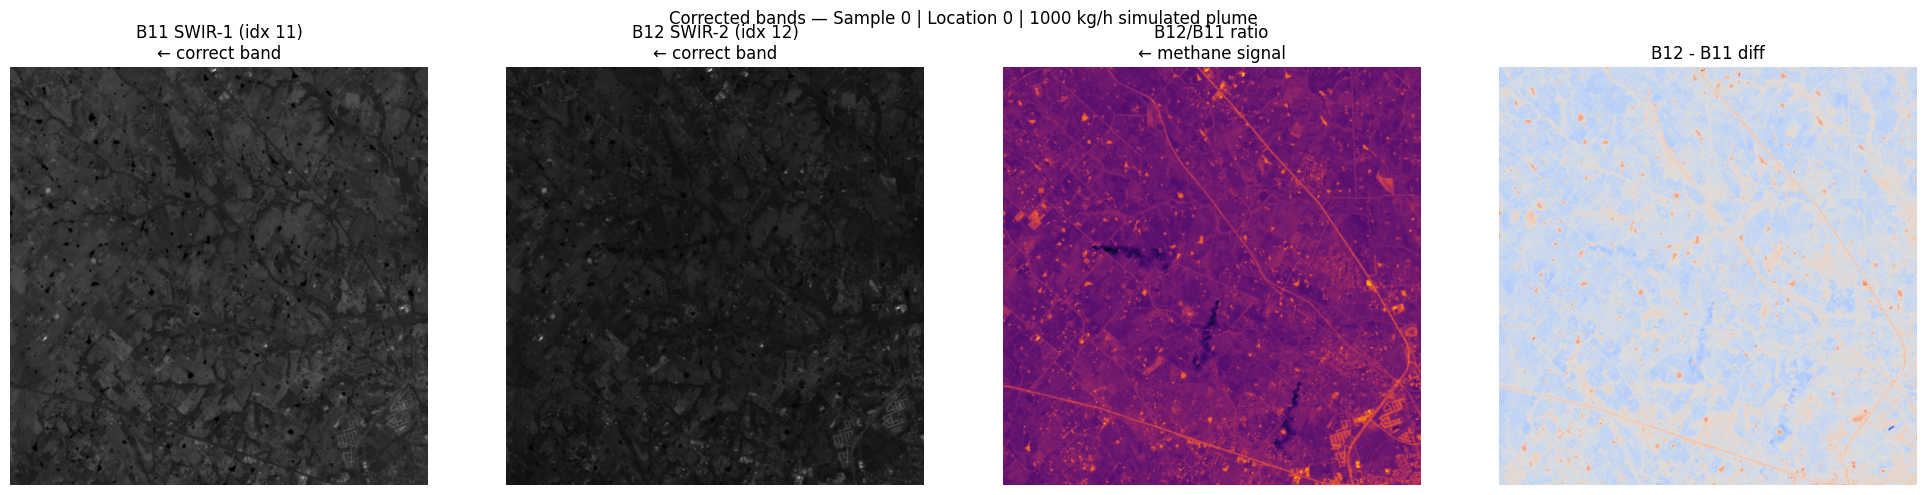

In [21]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(b11_correct, cmap="gray")
axes[0].set_title("B11 SWIR-1 (idx 11)\n← correct band")

axes[1].imshow(b12_correct, cmap="gray")
axes[1].set_title("B12 SWIR-2 (idx 12)\n← correct band")

axes[2].imshow(ratio_correct, cmap="inferno")
axes[2].set_title("B12/B11 ratio\n← methane signal")

axes[3].imshow(diff_correct, cmap="coolwarm")
axes[3].set_title("B12 - B11 diff")

plt.suptitle("Corrected bands — Sample 0 | Location 0 | 1000 kg/h simulated plume", fontsize=12)
for ax in axes: ax.axis("off")
plt.tight_layout()
plt.savefig("outputs/figures/corrected_bands_viz.png", dpi=150, bbox_inches="tight")
plt.show()

In [23]:
# Load label for first sample
label_files_list = sorted((RAW / "label").glob("*.tiff"))
lbl_path = label_files_list[0]

with rasterio.open(lbl_path) as src:
    lbl_raw = src.read(1).astype(np.float32)

print("Label shape      :", lbl_raw.shape)
print("Label min/max    :", lbl_raw.min(), "->", lbl_raw.max())
print("Non-zero pixels  :", (lbl_raw > 0).sum())
print("Pixels > 0.5     :", (lbl_raw > 0.5).sum())
print("Total pixels     :", lbl_raw.size)
print(f"Plume coverage   : {100*(lbl_raw > 0.5).sum()/lbl_raw.size:.2f}%")

# Threshold at 0.5 → binary mask
lbl_binary = (lbl_raw > 0.5).astype(np.float32)
print("\nBinary mask unique values:", np.unique(lbl_binary))
print("Binary plume pixels:", lbl_binary.sum())

Label shape      : (512, 512)
Label min/max    : 0.0 -> 1.0
Non-zero pixels  : 3255
Pixels > 0.5     : 2796
Total pixels     : 262144
Plume coverage   : 1.07%

Binary mask unique values: [0. 1.]
Binary plume pixels: 2796.0


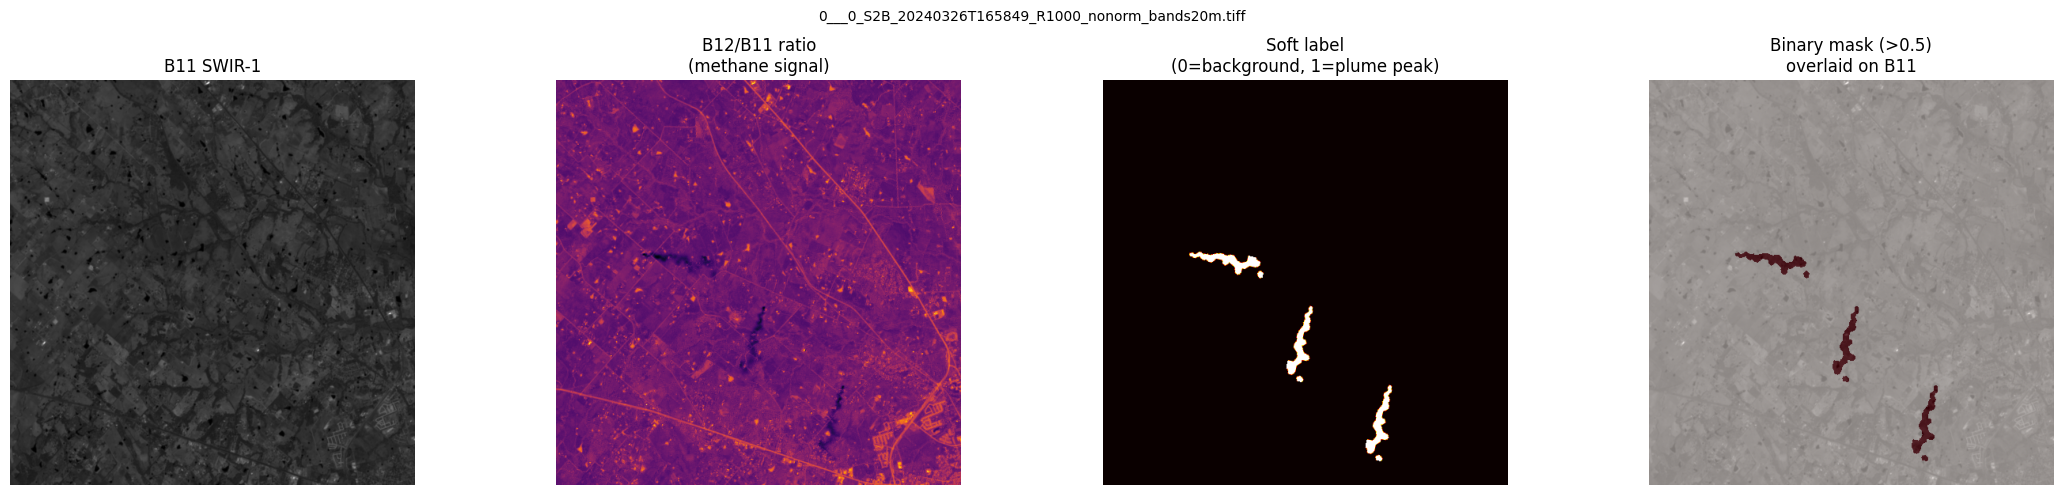

In [25]:
# Load matching image
img_path = all_files[0]
with rasterio.open(img_path) as src:
    img0 = src.read().astype(np.float32)

b11_0 = img0[11]
b12_0 = img0[12]
ratio_0 = (b12_0 + 1e-6) / (b11_0 + 1e-6)

fig, axes = plt.subplots(1, 4, figsize=(22, 5))

axes[0].imshow(b11_0, cmap="gray")
axes[0].set_title("B11 SWIR-1")

axes[1].imshow(ratio_0, cmap="inferno")
axes[1].set_title("B12/B11 ratio\n(methane signal)")

axes[2].imshow(lbl_raw, cmap="hot", vmin=0, vmax=1)
axes[2].set_title("Soft label\n(0=background, 1=plume peak)")

axes[3].imshow(b11_0, cmap="gray")
axes[3].imshow(lbl_binary, cmap="Reds", alpha=0.5)
axes[3].set_title("Binary mask (>0.5)\noverlaid on B11")

for ax in axes: ax.axis("off")
plt.suptitle(f"{img_path.name}", fontsize=10)
plt.tight_layout()
plt.savefig("outputs/figures/label_visualization.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
def pair_image_label(img_path, label_dir):
    """Match image file to its label file by shared stem identifier."""
    # Image: 0___0_S2B_20240326T165849_R1000_nonorm_bands20m.tiff
    # Label: 0___0_S2B_20240326T165849_R1000_bin_label.tiff
    stem = img_path.stem.replace("_nonorm_bands20m", "")
    label_path = label_dir / f"{stem}_bin_label.tiff"
    return label_path if label_path.exists() else None

# Test pairing
label_dir = RAW / "label"
paired = 0
missing = 0
for img_path in all_files:
    lbl = pair_image_label(img_path, label_dir)
    if lbl:
        paired += 1
    else:
        missing += 1

print(f"Successfully paired : {paired}")
print(f"Missing labels      : {missing}")
print(f"Total images        : {len(all_files)}")

Successfully paired : 804
Missing labels      : 0
Total images        : 804


In [29]:
# Count files per split — train.tar and val.tar extracted to same folder?
# Or are they in subdirs? Let's check
train_dir = RAW.parent.parent / "data" / "raw"
print("All tiff files are in one flat folder:", RAW)

# Let's look at file names - the split info might come from the zenodo structure
# val.tar and train.tar - check if there's a subfolder
val_imgs  = [f for f in all_files if "val"   in str(f)]
train_imgs = [f for f in all_files if "train" in str(f)]
print(f"\nFiles with 'val' in path  : {len(val_imgs)}")
print(f"Files with 'train' in path: {len(train_imgs)}")
print(f"\nTotal files: {len(all_files)}")
print("\nAll files appear to be in:", set(f.parent for f in all_files[:5]))

All tiff files are in one flat folder: data/raw

Files with 'val' in path  : 0
Files with 'train' in path: 0

Total files: 804

All files appear to be in: {PosixPath('data/raw')}


In [31]:
# Since files are flat, we split by sample_id
# sample_id=0 means plume present (injected), other sample IDs = background

print("Sample ID distribution:")
print(meta_df["sample_id"].value_counts().sort_index())

print("\nBreakdown:")
print(f"  sample_id=0 (plume)     : {(meta_df['sample_id']==0).sum()} files")
print(f"  sample_id!=0 (no plume) : {(meta_df['sample_id']!=0).sum()} files")

# Assign plume label based on sample_id
meta_df["has_plume"] = (meta_df["sample_id"] == 0).astype(int)
print("\nClass balance:")
print(meta_df["has_plume"].value_counts())

Sample ID distribution:
sample_id
0      16
10     16
11     17
12     17
13     15
100    15
101    14
102    15
103    16
104    15
105    13
106    15
107    16
108    16
109    16
110    17
111    15
112    15
113    13
114    15
115    17
116    15
117    15
118    16
119    17
120    14
121    15
122    17
123    15
124    17
125    16
126    16
127    16
128    15
129    17
130    16
131    16
132    16
133    15
134    16
135    16
136    15
138    15
139    16
140    16
141    16
142    16
143    16
144    15
145    14
146    13
147    12
Name: count, dtype: int64

Breakdown:
  sample_id=0 (plume)     : 16 files
  sample_id!=0 (no plume) : 788 files

Class balance:
has_plume
0    788
1     16
Name: count, dtype: int64


In [33]:
# Check a few non-plume labels to confirm they're zero maps
non_plume_imgs = meta_df[meta_df["sample_id"] != 0]["path"].values[:5]

print("Checking 5 background tile labels:")
for img_path in non_plume_imgs:
    lbl_path = pair_image_label(img_path, label_dir)
    with rasterio.open(lbl_path) as src:
        lbl = src.read(1)
    has_signal = (lbl > 0.5).sum()
    print(f"  {img_path.name[:40]}... → plume pixels: {has_signal}")

Checking 5 background tile labels:
  100___0_S2B_20240326T165849_R1000_nonorm... → plume pixels: 929
  100___0_S2B_20240405T165849_R1000_nonorm... → plume pixels: 924
  100___1_S2A_20240307T085821_R1000_nonorm... → plume pixels: 931
  100___1_S2A_20240317T085711_R1000_nonorm... → plume pixels: 926
  100___2_S2A_20240420T065621_R1000_nonorm... → plume pixels: 923


In [35]:
from sklearn.model_selection import train_test_split

# Separate plume and background
plume_df = meta_df[meta_df["sample_id"] == 0].reset_index(drop=True)
bg_df    = meta_df[meta_df["sample_id"] != 0].reset_index(drop=True)

print(f"Plume tiles     : {len(plume_df)}")
print(f"Background tiles: {len(bg_df)}")

# Split each class 80/20
plume_train, plume_val = train_test_split(plume_df, test_size=0.2, random_state=42)
bg_train,    bg_val    = train_test_split(bg_df,    test_size=0.2, random_state=42)

# Combine
train_df = pd.concat([plume_train, bg_train]).reset_index(drop=True)
val_df   = pd.concat([plume_val,   bg_val  ]).reset_index(drop=True)

print(f"\nTrain: {len(train_df)} total | {train_df['has_plume'].sum()} plume | {(train_df['has_plume']==0).sum()} background")
print(f"Val  : {len(val_df)} total | {val_df['has_plume'].sum()} plume | {(val_df['has_plume']==0).sum()} background")

Plume tiles     : 16
Background tiles: 788

Train: 642 total | 12 plume | 630 background
Val  : 162 total | 4 plume | 158 background


In [37]:
import torch
from torch.utils.data import Dataset, DataLoader

class MethaneDataset(Dataset):
    def __init__(self, dataframe, label_dir, device="mps"):
        self.df        = dataframe.reset_index(drop=True)
        self.label_dir = Path(label_dir)
        self.device    = device

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["path"]
        lbl_path = pair_image_label(img_path, self.label_dir)

        # Load image — all 13 bands
        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float32)  # (13, 512, 512)

        # Extract B11 (idx 11) and B12 (idx 12)
        b11 = img[11]
        b12 = img[12]
        eps = 1e-6

        # Normalize each band to 0-1 using percentile clipping
        def norm(x):
            lo, hi = np.percentile(x, 2), np.percentile(x, 98)
            return np.clip((x - lo) / (hi - lo + eps), 0, 1)

        b11_n = norm(b11)
        b12_n = norm(b12)
        ratio = (b12_n + eps) / (b11_n + eps)
        diff  = b12_n - b11_n

        # Stack 4 channels: (4, 512, 512)
        x = np.stack([b11_n, b12_n, ratio, diff], axis=0).astype(np.float32)

        # Load label → tile-level binary label
        with rasterio.open(lbl_path) as src:
            lbl_map = src.read(1).astype(np.float32)
        tile_label = float((lbl_map > 0.5).sum() > 0)  # 1.0 if any plume pixel

        return (
            torch.tensor(x, dtype=torch.float32),
            torch.tensor(tile_label, dtype=torch.float32)
        )

# Test it on one sample
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
dataset = MethaneDataset(train_df, label_dir)
x_sample, y_sample = dataset[0]

print("Input tensor shape :", x_sample.shape)    # expect (4, 512, 512)
print("Input dtype        :", x_sample.dtype)
print("Label              :", y_sample.item())
print("Channel ranges:")
for i, name in enumerate(["B11","B12","ratio","diff"]):
    ch = x_sample[i]
    print(f"  {name}: min={ch.min():.3f} max={ch.max():.3f} mean={ch.mean():.3f}")

Input tensor shape : torch.Size([4, 512, 512])
Input dtype        : torch.float32
Label              : 1.0
Channel ranges:
  B11: min=0.000 max=1.000 mean=0.466
  B12: min=0.000 max=1.000 mean=0.460
  ratio: min=0.000 max=404412.781 mean=647.662
  diff: min=-0.901 max=0.547 mean=-0.006


In [41]:
train_dataset = MethaneDataset(train_df, label_dir)
val_dataset   = MethaneDataset(val_df,   label_dir)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,       # safe for M2 Pro MPS
    shuffle=True,
    num_workers=0       # important: keep 0 on Mac to avoid multiprocessing issues
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

# Sanity check — load one batch
batch_x, batch_y = next(iter(train_loader))
print("Batch x shape :", batch_x.shape)   # expect (4, 4, 512, 512)
print("Batch y shape :", batch_y.shape)   # expect (4,)
print("Batch labels  :", batch_y.tolist())
print("DataLoader working")

Batch x shape : torch.Size([4, 4, 512, 512])
Batch y shape : torch.Size([4])
Batch labels  : [1.0, 1.0, 1.0, 1.0]
DataLoader working


In [43]:
# Check ALL samples have plumes
plume_counts = []
for img_path in all_files[:20]:
    lbl_path = pair_image_label(img_path, label_dir)
    with rasterio.open(lbl_path) as src:
        lbl = src.read(1)
    plume_counts.append((lbl > 0.5).sum())

print("Plume pixel counts for first 20 tiles:")
for f, c in zip(all_files[:20], plume_counts):
    print(f"  {f.name[:50]} → {c} plume pixels")

Plume pixel counts for first 20 tiles:
  0___0_S2B_20240326T165849_R1000_nonorm_bands20m.ti → 2796 plume pixels
  0___0_S2B_20240405T165849_R1000_nonorm_bands20m.ti → 929 plume pixels
  0___1_S2A_20240307T085821_R1000_nonorm_bands20m.ti → 932 plume pixels
  0___1_S2A_20240317T085711_R1000_nonorm_bands20m.ti → 934 plume pixels
  0___2_S2A_20240420T065621_R1000_nonorm_bands20m.ti → 1858 plume pixels
  0___2_S2B_20240306T065739_R1000_nonorm_bands20m.ti → 932 plume pixels
  0___3_S2A_20240314T070651_R1000_nonorm_bands20m.ti → 1863 plume pixels
  0___3_S2B_20240617T070629_R1000_nonorm_bands20m.ti → 1858 plume pixels
  0___5_S2B_20240311T160949_R1000_nonorm_bands20m.ti → 933 plume pixels
  0___5_S2B_20240520T160829_R1000_nonorm_bands20m.ti → 923 plume pixels
  0___6_S2A_20240306T093031_R1000_nonorm_bands20m.ti → 933 plume pixels
  0___6_S2A_20240528T094031_R1000_nonorm_bands20m.ti → 1861 plume pixels
  0___8_S2B_20240307T094739_R1000_nonorm_bands20m.ti → 924 plume pixels
  0___8_S2B_20240314

In [45]:
# Proper split: keep same locations together
# locations 0-7: train, locations 8-9: val
train_df = meta_df[meta_df["location_id"].isin([0,1,2,3,4,5,6,7])].reset_index(drop=True)
val_df   = meta_df[meta_df["location_id"].isin([8,9])].reset_index(drop=True)

print(f"Train: {len(train_df)} tiles | Locations: {sorted(train_df['location_id'].unique())}")
print(f"Val  : {len(val_df)} tiles | Locations: {sorted(val_df['location_id'].unique())}")

Train: 619 tiles | Locations: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Val  : 185 tiles | Locations: [np.int64(8), np.int64(9)]


In [47]:
class MethaneSegDataset(Dataset):
    def __init__(self, dataframe, label_dir):
        self.df        = dataframe.reset_index(drop=True)
        self.label_dir = Path(label_dir)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = row["path"]
        lbl_path = pair_image_label(img_path, self.label_dir)

        # Load image
        with rasterio.open(img_path) as src:
            img = src.read().astype(np.float32)  # (13, 512, 512)

        b11 = img[11]
        b12 = img[12]
        eps = 1e-6

        # Normalize each band with percentile clipping
        def norm(x):
            lo, hi = np.percentile(x, 2), np.percentile(x, 98)
            return np.clip((x - lo) / (hi - lo + eps), 0, 1).astype(np.float32)

        b11_n = norm(b11)
        b12_n = norm(b12)
        ratio = np.clip((b12_n + eps) / (b11_n + eps), 0, 5).astype(np.float32)
        diff  = (b12_n - b11_n).astype(np.float32)

        # Stack 4 channels: (4, 512, 512)
        x = np.stack([b11_n, b12_n, ratio, diff], axis=0)

        # Load segmentation mask
        with rasterio.open(lbl_path) as src:
            lbl = src.read(1).astype(np.float32)
        mask = (lbl > 0.5).astype(np.float32)  # (512, 512) binary

        return (
            torch.tensor(x,    dtype=torch.float32),
            torch.tensor(mask, dtype=torch.float32).unsqueeze(0)  # (1, 512, 512)
        )

# Test
dataset = MethaneSegDataset(train_df, label_dir)
x, mask = dataset[0]
print("Input shape :", x.shape)       # (4, 512, 512)
print("Mask shape  :", mask.shape)    # (1, 512, 512)
print("Mask dtype  :", mask.dtype)
print("Plume pixels:", mask.sum().item())
print("Channel ranges after fix:")
for i, name in enumerate(["B11","B12","ratio","diff"]):
    ch = x[i]
    print(f"  {name}: min={ch.min():.3f}  max={ch.max():.3f}  mean={ch.mean():.3f}")

Input shape : torch.Size([4, 512, 512])
Mask shape  : torch.Size([1, 512, 512])
Mask dtype  : torch.float32
Plume pixels: 2796.0
Channel ranges after fix:
  B11: min=0.000  max=1.000  mean=0.474
  B12: min=0.000  max=1.000  mean=0.370
  ratio: min=0.000  max=5.000  mean=0.793
  diff: min=-0.534  max=0.580  mean=-0.103


In [49]:
train_dataset = MethaneSegDataset(train_df, label_dir)
val_dataset   = MethaneSegDataset(val_df,   label_dir)

train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,  num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=2, shuffle=False, num_workers=0)

# Sanity check batch
bx, bm = next(iter(train_loader))
print("Batch input shape :", bx.shape)    # (2, 4, 512, 512)
print("Batch mask shape  :", bm.shape)    # (2, 1, 512, 512)
print("Plume px per tile :", bm.sum(dim=(1,2,3)).tolist())
print("Segmentation DataLoader ready")

Batch input shape : torch.Size([2, 4, 512, 512])
Batch mask shape  : torch.Size([2, 1, 512, 512])
Plume px per tile : [932.0, 933.0]
Segmentation DataLoader ready
